In [1]:
# libraries for data loading and system/path settings
import json
import sys
import warnings
import os
from pathlib import Path
import random
import matplotlib.pyplot as plt

# libraries for model building and training
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForTokenClassification, logging
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm

# set path to project root and import custom classes and functions
base_path = Path.cwd() / "../../"
sys.path.append(str(base_path.resolve()))
from utils.classification import EarlyStopping
from utils.evaluation import run_testset_ner, evaluate_seqeval

# global settings to suppress unproblematic warning messages
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="The sentencepiece tokenizer")

In [2]:
# load the annotated data in json format
with open("../../01_data/annotations_reduced.json", "r") as f:
    data = json.load(f)

# initialize tag dictionary
tag_dict = {"O"}

# loop through all sentences
for task in data:
    if task["annotations"]:
        for annotation in task["annotations"]:
            label = annotation["tag"][0:2]
            tag_dict.add(f"B-{label}")
            tag_dict.add(f"I-{label}")

# sort the tag dictionary
tag_list = sorted(tag_dict)

# dictionaries that convert from id to tag and vice versa
tag_to_id = {tag: i for i, tag in enumerate(tag_list)}
id_to_tag = {id: label for label, id in tag_to_id.items()}

In [3]:
def tokenization_labelling(text, entities, tokenizer, tag2id, max_len):

    # get the encoding of the sentence
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True,
                         max_length=max_len, padding="max_length")
    
    # create preliminary list with O tags for all tokens
    tags = ["O"] * len(encoding.offset_mapping)

    # loop over annotations and extract start and end index as well as the given tag
    for ent in entities:
        start, end = ent["start"], ent["end"]
        ent_tag = ent["tag"][0:2]

        # loop over all tokens in the sentence and check for overlap
        for idx, (token_start, token_end) in enumerate(encoding.offset_mapping):
            # continue if it is a special token
            if token_start == token_end == 0:
                continue
            # check for overlap (overlap checking strictly necessary for deberta)
            if token_end > start and token_start < end:
                # assign B-tag if start is equal or smaller (smaller if deberta)
                if token_start <= start:
                    tags[idx] = f"B-{ent_tag}"
                # otherwise it is an inside token
                else:
                    tags[idx] = f"I-{ent_tag}"

    # extract the word ids
    word_ids = encoding.word_ids()

    # ensure propagate B-tags are propagated to all subwords of the same word (only actually relevant for deberta)
    for idx, wid in enumerate(word_ids):
        if wid is None:
            continue
        # if token has B-tag ensure that all other tokens of the same word get I-tag
        if tags[idx].startswith("B-"):
            for j, wid2 in enumerate(word_ids):
                if wid2 == wid and j != idx:
                    tags[j] = f"I-{ent_tag}"

    # convert tags to IDs, masking special tokens
    tag_ids = [-100 if wid is None else tag2id.get(tag, tag2id["O"])
               for tag, wid in zip(tags, encoding.word_ids())]

    return encoding["input_ids"], encoding["attention_mask"], tag_ids, word_ids

In [4]:
class TokenDataset(Dataset):
    def __init__(self, data, tokenizer, tag2id, max_len):
        self.dataset = []
        self.max_len = max_len

        for task in data:
            # get the sentence and all annotations
            text = task["sentence"]
            spans = task["annotations"]

            # tokenize and get all ids
            input_ids, attention_mask, tag_ids, word_ids = tokenization_labelling(text, spans, tokenizer, tag2id, self.max_len)

            # add everything to the dataset list
            self.dataset.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
                "tag_ids": torch.tensor(tag_ids, dtype=torch.long),
                "word_ids": word_ids})
  

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

def custom_collate_fn(batch):
    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_masks = torch.stack([item["attention_mask"] for item in batch])
    tag_ids = torch.stack([item["tag_ids"] for item in batch])
    word_ids = [item["word_ids"] for item in batch]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks,
        "tag_ids": tag_ids,
        "word_ids": word_ids
    }

In [17]:
# set different dataset sizes to test
data_sizes = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
f1_scores = []

# set the model and hyperparameters with which I want to test
model_name = "roberta-base"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
lr = 9e-06
weight_decay = 0.01
batch_size = 32
epochs = 10
tokenizer = AutoTokenizer.from_pretrained(model_name)

for size in data_sizes:

    print(f"\nTesting performance with size {size}")
    # create the model, optimizer and early stopper
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(tag_to_id),
        id2label=id_to_tag,
        label2id=tag_to_id
    ).to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopper = EarlyStopping(patience=3, min_delta=0.0001, save_model=True, path=f"model_checkpoints/roberta-base-{size}.pt", printoption=False)

    # take random subset according to the size
    data_subset = random.sample(data, k=size)

    # split into training and validation set (validation here for early stopping)
    train_data, val_data = train_test_split(data_subset, test_size=0.2, shuffle=True, random_state=42)

    # create tensor datasets
    train_dataset = TokenDataset(data=train_data, tokenizer=tokenizer, tag2id=tag_to_id, max_len=128)
    val_dataset = TokenDataset(data=val_data, tokenizer=tokenizer, tag2id=tag_to_id, max_len=128)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

    # set model to training mode and run the training loop
    for epoch in range(epochs):
        model.train()
        print(f"Epoch {epoch + 1}/{epochs}")
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc="Training")
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_masks = batch["attention_mask"].to(device)
            tag_ids = batch["tag_ids"].to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type="mps", dtype=torch.float16):
                outputs = model(input_ids=input_ids, attention_mask=attention_masks, labels=tag_ids)
                loss = outputs.loss
                total_loss += loss.item()

            loss.backward()
            clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            progress_bar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_dataloader)
        print(f"Average training loss: {avg_loss:.4f}")

        # run validation data through model and get seqeval f1-score
        all_true, all_pred, _ = run_testset_ner(
            model=model, test_dataloader=val_dataloader, id2tag=id_to_tag, device=device, for_metric="seqeval"
            )
        val_metrics = evaluate_seqeval(all_true, all_pred)
        val_f1 = val_metrics["f1"]

        # feed validation loss into early stopping object to save and stop model training if necessary
        early_stopper(val_f1, model, epoch)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break
    
    # load the best model from path
    best_model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(tag_to_id),
        id2label=id_to_tag,
        label2id=tag_to_id
    )
    state_dict = torch.load(f"model_checkpoints/roberta-base-{size}.pt", map_location="cpu")
    best_model.load_state_dict(state_dict)
    best_model.to(device)

    # evaluate the best model on the held-out test set
    all_true, all_pred, _ = run_testset_ner(
        model=best_model, test_dataloader=val_dataloader, id2tag=id_to_tag, device=device, for_metric="seqeval"
        )
    metrics = evaluate_seqeval(all_true, all_pred)
    f1 = metrics["f1"]

    # get the best f1 score and append to list
    f1_scores.append(f1)

    print("-"*200)


Testing performance with size 500
Epoch 1/10


Training: 100%|██████████| 13/13 [00:12<00:00,  1.08it/s, loss=0.177]


Average training loss: 0.4774
Epoch 2/10


Training: 100%|██████████| 13/13 [00:09<00:00,  1.33it/s, loss=0.211]


Average training loss: 0.2391
Epoch 3/10


...

Average training loss: 0.0116
Epoch 10/10


Training: 100%|██████████| 38/38 [00:31<00:00,  1.21it/s, loss=0.00999]


Average training loss: 0.0080
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Testing performance with size 2000
Epoch 1/10


Training:  24%|██▍       | 12/50 [00:10<00:33,  1.14it/s, loss=0.295]


KeyboardInterrupt: 

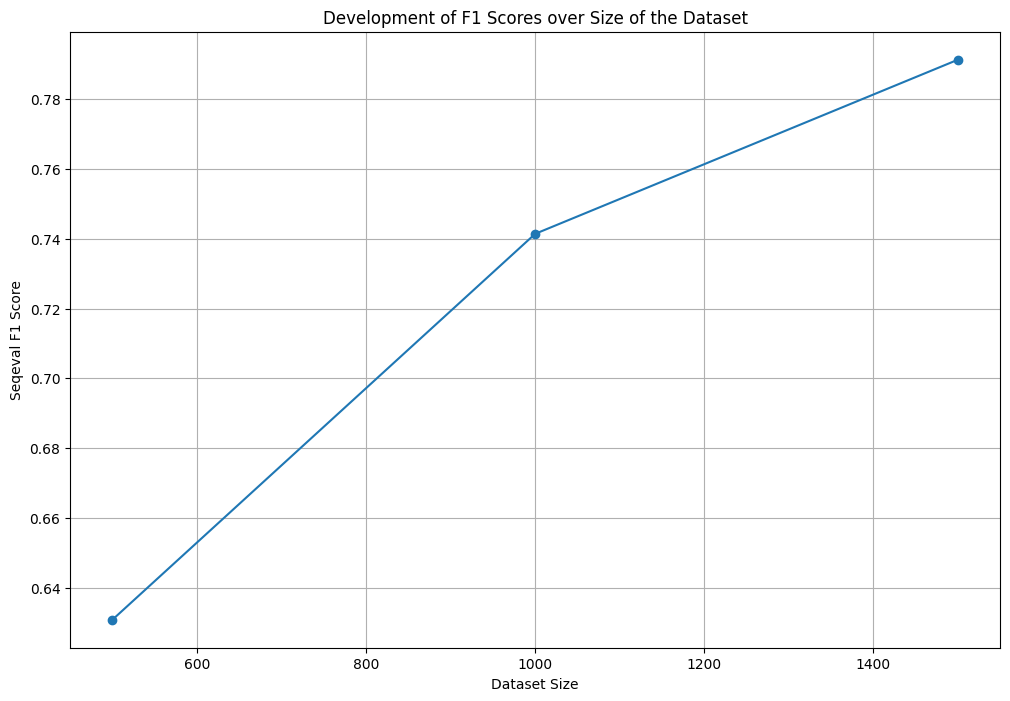

In [19]:
# plot the trajectory
plt.figure(figsize=(12,8))
plt.plot(data_sizes[:len(f1_scores)], f1_scores, marker='o')
plt.title("Development of F1 Scores over Size of the Dataset")
plt.xlabel("Dataset Size")
plt.ylabel("Seqeval F1 Score")
plt.grid(True)
plt.show()

In [ ]:
# do the same with augmented data added